# 8.0) Regressão Logística - Base Crédito

In [1]:
import pickle
with open('../2-3-Classificacao/credit_aula.pkl', 'rb') as f:
  X_credit_treinamento, y_credit_treinamento, X_credit_teste, y_credit_teste = pickle.load(f)

In [2]:
X_credit_treinamento.shape, y_credit_treinamento.shape

((24435, 3), (24435,))

In [3]:
X_credit_teste.shape, y_credit_teste.shape

((8146, 3), (8146,))

### dados credit => [person_income, person_age, loan_amnt | loan_status]

In [5]:
from sklearn.linear_model import LogisticRegression

In [6]:
logistic_credit = LogisticRegression(random_state=1) # random_state=1 sempre que rodará gerará os mesmos números.
logistic_credit.fit(X_credit_treinamento, y_credit_treinamento) # atributos do treinamento

LogisticRegression(random_state=1)

In [7]:
# verificar o parâmetro utilizado

print(logistic_credit.get_params())

{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 100, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 1, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


In [8]:
logistic_credit.intercept_  #B0

array([-0.49442564])

In [11]:
print('equivale ao parâmetro b0 =  {}'.format(logistic_credit.intercept_[0]))

equivale ao parâmetro b0 =  -0.4944256421647591


In [9]:
logistic_credit.coef_ # coeficiente

array([[-3.44680577e-05,  2.10520701e-03,  1.14025313e-04]])

B1, B2 e B3

In [13]:
print(f'achar os coeficientes b1, b2 e b3: {logistic_credit.coef_[0]}')

achar os coeficientes b1, b2 e b3: [-3.44680577e-05  2.10520701e-03  1.14025313e-04]


regressão linear, previsão de números

a ideia é encontrar o parâmetro
b0 e b1

$$
y = b_{0} + b_{1}. x_{person income} + b_{2}. x_{person age} + b_{3}. x_{Loan Amnt}
$$


regressão linear
x = idade
y = pagar






$$
p = \frac{1}{1 + e^{-y}}
$$

$$
1 + e^{-y} = \frac{1}{p}
$$


$$
e^{-y} = \frac{1}{p} - 1
$$


$$
- y = \ln\left(\frac{1}{p} - 1\right)
$$


$$
y = -\ln\left(\frac{1}{p} - 1\right)
$$


1 pessoa que não paga

0 pessoa que paga


### 1) algoritmo por de trás dos panos calcula os dados



In [15]:
previsoes = logistic_credit.predict(X_credit_teste)
previsoes

array([0, 0, 0, ..., 0, 0, 0])

In [17]:
previsoes[:500]

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [18]:
y_credit_teste[:500]

array([0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0,

In [19]:
from sklearn.metrics import accuracy_score, classification_report
accuracy_score(y_credit_teste, previsoes)

0.8076356493984778

In [21]:
acuracia = accuracy_score(y_credit_teste, previsoes)
print(f'Acurácia da Regressão Logística {acuracia*100:.2f} %')

Acurácia da Regressão Logística 80.76 %


In [22]:
# acurácia
# comparando com a outra árvore de decisão da base de crédito -> 3-2_Arvore_decisao_parte3_basecredito.ipynb
# a acurácia foi de 81.57 %.
# random forest (muitas árvores) acurácia de 84,21% -> 3-4_Arvore_decision_Random_Forest.ipynb
#  Acurácia do modelo de regras foi de 82.68 % 4-2_InducaoporRegras-BaseCredito.ipynb

# Acurácia da indução de Regras Base Credit do modelo 78.18% 4-3_InducaodeRegras_Base_Credit-Majority_Learner.ipynb 
# ou seja, vale a pena utilizar todos os outros algoritmos utilizados. 

# Acurácia da instância KNN 84.27 %, com o n_neighbors=10
#Acurácia da instância KNN 82.76 %, com o n_neighbors=5 - ideal pois acertou mais o 1x1 que é o mais importante, que não paga
# 5-1KNN_BaseCredit.ipynb



Visualizar a matriz de confusão 

0.8076356493984778

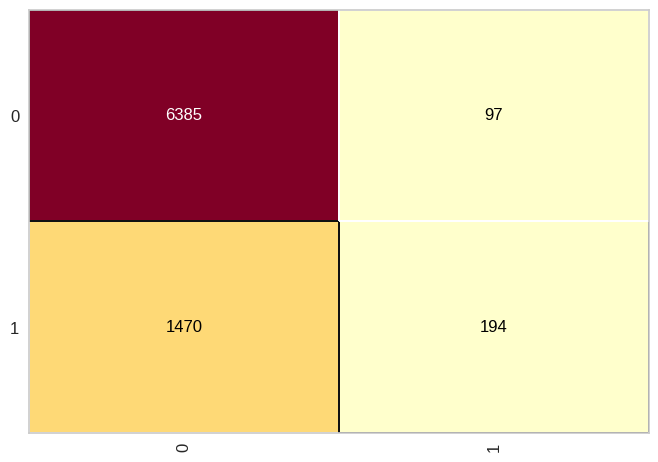

In [23]:
from yellowbrick.classifier import ConfusionMatrix
cm = ConfusionMatrix(logistic_credit)
cm.fit(X_credit_treinamento, y_credit_treinamento)
cm.score(X_credit_teste, y_credit_teste)

# ficou ruim na previsão do não pagam

In [24]:
print(classification_report(y_credit_teste, previsoes))

              precision    recall  f1-score   support

           0       0.81      0.99      0.89      6482
           1       0.67      0.12      0.20      1664

    accuracy                           0.81      8146
   macro avg       0.74      0.55      0.54      8146
weighted avg       0.78      0.81      0.75      8146



recall o quando identifica cada classe 0 com 99%, e com precisão de 81%

1 recall identifica apenas 12% com precisão de 67%

0.633439725018414

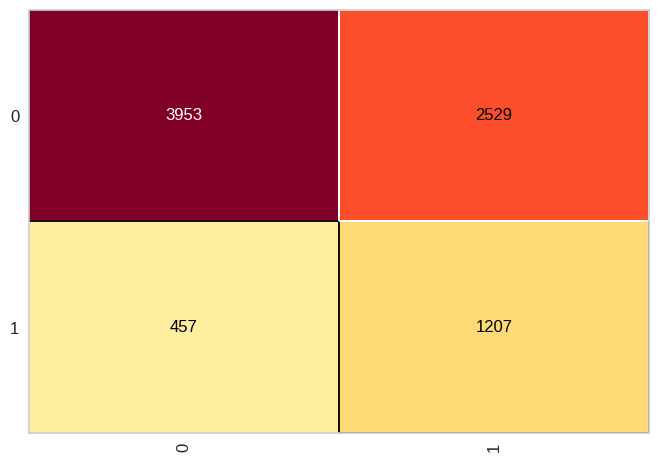

In [26]:
from sklearn.linear_model import LogisticRegression
from yellowbrick.classifier import ConfusionMatrix

# Regressão logística ajustando o peso das classes
logistic_credit = LogisticRegression(random_state=1, class_weight='balanced')
logistic_credit.fit(X_credit_treinamento, y_credit_treinamento)

previsoes = logistic_credit.predict(X_credit_teste)
previsoes


# Matriz de confusão
from yellowbrick.classifier import ConfusionMatrix
cm = ConfusionMatrix(logistic_credit)
cm.fit(X_credit_treinamento, y_credit_treinamento)
cm.score(X_credit_teste, y_credit_teste)

In [27]:
print(logistic_credit.get_params())

{'C': 1.0, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 100, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 1, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


In [28]:
print('equivale ao parâmetro b0 =  {}'.format(logistic_credit.intercept_[0]))

print(f'achar os coeficientes b1, b2 e b3: {logistic_credit.coef_[0]}')

equivale ao parâmetro b0 =  0.49680502881187666
achar os coeficientes b1, b2 e b3: [-2.76815313e-05  2.53803801e-03  1.00319589e-04]


In [29]:
print(classification_report(y_credit_teste, previsoes))

              precision    recall  f1-score   support

           0       0.90      0.61      0.73      6482
           1       0.32      0.73      0.45      1664

    accuracy                           0.63      8146
   macro avg       0.61      0.67      0.59      8146
weighted avg       0.78      0.63      0.67      8146



In [30]:
acuracia = accuracy_score(y_credit_teste, previsoes)
print(f'Acurácia da Regressão Logística {acuracia*100:.2f} %')

Acurácia da Regressão Logística 63.34 %
